# MATH GR5360 Final Project — Notebook 2
## Channel WithDDControl Strategy & Walk-Forward Optimization

**Columbia University — Mathematical Methods in Financial Price Analysis**

**Group 1** — Primary: **TY** (10-Year US Treasury Futures) &nbsp;&nbsp;•&nbsp;&nbsp; Secondary: **BTC** (Bitcoin)

---

### Purpose

This notebook implements the **Channel WithDDControl** trend-following strategy (exact port of the course-provided `main.m`), validates it on a single parameter pair, then runs a rolling **walk-forward optimisation** over a parameter grid $(L, S)$ = (ChnLen, StpPct).

Switch between our primary and secondary market by toggling `MARKET_SELECT` below.

In [1]:
# ============================================================================
# MARKET SELECTOR — toggle between our primary and secondary market
# ============================================================================
MARKET_SELECT = 'TY'     # 'TY' (primary, 10-Year Treasury Futures) or 'BTC' (secondary)

In [2]:
# ============================================================================
# MARKET PARAMETERS DATABASE + AUTO-CONFIG
# ============================================================================
MARKET_DATABASE = {
    # Ticker: (Name, Exchange, PV, Slippage, TickValue, PV_Multiplier)
    'BO': ('Soybean Oil',      'CBOT-CME',       600,  39,     6,     1),
    'DX': ('Dollar Index',     'NYBOT-ICE',      1000, 16.5,   5,     1),
    'HG': ('Copper',           'COMEX-NYMEX-CME', 250, 59.25, 12.5,   1),
    'HO': ('Heating Oil',      'NYMEX-CME',      420,  70.2,   4.2, 100),
    'JO': ('Orange Juice',     'NYBOT-ICE',      150, 183,     7.5,   1),
    'JY': ('Japanese Yen',     'CME',            1250, 53,     6.25,100),
    'SY': ('Soybeans',         'CBOT-CME',        50,  35.5,  12.5,   1),
    'SB': ('Sugar #11',        'NYBOT-ICE',     1120,  56.76, 11.2,   1),
    'SF': ('Swiss Franc',      'CME',           1250,  25.5,  12.5, 100),
    'TU': ('2-Year Treasury',  'CBOT-CME',      2000,  18.625,15.625, 1),
    'TY': ('10-Year Treasury', 'CBOT-CME',      1000,  18.625,15.625, 1),
    'WC': ('Wheat',            'CBOT-CME',        50,  30.5,  12.5,   1),
    'SM': ('Soybean Meal',     'CBOT-CME',       100,  57,    10,     1),
    'CC': ('Cocoa',            'NYBOT-ICE',       10, 103,    10,     1),
    'BZ': ('Schatz',           'EUREX',         1000,  10.5,   5,     1),
    'CL': ('Crude Oil WTI',    'NYMEX-CME',     1000,  46,    10,     1),
    'GC': ('Gold 100oz',       'COMEX-NYMEX-CME',100,  65,    10,     1),
    'SV': ('Silver',           'COMEX-NYMEX-CME',5000,243,    25,  0.01),
    'BTC':('Bitcoin',          'CME / Spot',       5,  50,    25,     1),
}

assert MARKET_SELECT in MARKET_DATABASE, f"Unknown market: {MARKET_SELECT}"
TICKER = MARKET_SELECT
_info = MARKET_DATABASE[TICKER]

MARKET = {
    'ticker':        TICKER,
    'name':          _info[0],
    'exchange':      _info[1],
    'PV':            _info[2],
    'slpg':          _info[3],
    'tick_value':    _info[4],
    'pv_multiplier': _info[5],
    'E0':            100000,
}
DATA_FILE = f'../data/{TICKER}-5minHLV.csv'

print("=" * 72)
print(f"MARKET: {MARKET['ticker']} — {MARKET['name']}  ({MARKET['exchange']})")
print(f"PV=${MARKET['PV']}, Slippage=${MARKET['slpg']}, E0=${MARKET['E0']:,}")
print(f"Data file: {DATA_FILE}")
print("=" * 72)

MARKET: TY — 10-Year Treasury  (CBOT-CME)
PV=$1000, Slippage=$18.625, E0=$100,000
Data file: ../data/TY-5minHLV.csv


In [3]:
# ============================================================================
# IMPORTS + COLUMBIA THEME
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from numba import jit
from tqdm.notebook import tqdm
from datetime import datetime
from typing import Tuple
import warnings
warnings.filterwarnings('ignore')

# Columbia visual identity
COLUMBIA_BLUE   = '#B9D9EB'
COLUMBIA_CORE   = '#75AADB'
COLUMBIA_NAVY   = '#012169'
COLUMBIA_DARK   = '#1D4F91'
COLUMBIA_ACCENT = '#C4D8E2'
COLUMBIA_GREY   = '#4B4B4B'
COLUMBIA_WARM   = '#E08119'
COLUMBIA_RED    = '#8B0000'

COLUMBIA_CMAP = LinearSegmentedColormap.from_list(
    'columbia', [COLUMBIA_NAVY, COLUMBIA_DARK, COLUMBIA_CORE, COLUMBIA_BLUE, '#FFFFFF'])
COLUMBIA_DIVERGING = LinearSegmentedColormap.from_list(
    'columbia_div', [COLUMBIA_RED, COLUMBIA_WARM, '#FFFFFF', COLUMBIA_CORE, COLUMBIA_NAVY])

mpl.rcParams.update({
    'figure.figsize':      (14, 6),
    'figure.facecolor':    'white',
    'axes.facecolor':      'white',
    'axes.edgecolor':      COLUMBIA_NAVY,
    'axes.labelcolor':     COLUMBIA_NAVY,
    'axes.titlecolor':     COLUMBIA_NAVY,
    'axes.titleweight':    'bold',
    'axes.titlesize':      13,
    'axes.grid':           True,
    'grid.color':          COLUMBIA_ACCENT,
    'grid.alpha':          0.55,
    'grid.linewidth':      0.7,
    'xtick.color':         COLUMBIA_NAVY,
    'ytick.color':         COLUMBIA_NAVY,
    'legend.frameon':      True,
    'legend.edgecolor':    COLUMBIA_NAVY,
    'lines.linewidth':     1.3,
    'font.size':           11,
    'font.family':         'DejaVu Sans',
})

print(f"Notebook started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Theme: Columbia Blue  |  Market: {MARKET['ticker']} ({MARKET['name']})")

Notebook started: 2026-04-17 00:28:12
Theme: Columbia Blue  |  Market: TY (10-Year Treasury)


---
## 1. Load Data

In [4]:
def load_data(filepath):
    """Load OHLC CSV; column-agnostic and date/time-agnostic."""
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.lower()
    if 'date' in df.columns and 'time' in df.columns:
        df['datetime'] = pd.to_datetime(
            df['date'].astype(str) + ' ' + df['time'].astype(str), format='mixed')
    elif 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
    else:
        df['datetime'] = pd.to_datetime(df.iloc[:, 0])
    df.set_index('datetime', inplace=True)
    df.sort_index(inplace=True)
    rename = {}
    for c in df.columns:
        cl = c.lower()
        if   'open'  in cl: rename[c] = 'Open'
        elif 'high'  in cl: rename[c] = 'High'
        elif 'low'   in cl: rename[c] = 'Low'
        elif 'close' in cl: rename[c] = 'Close'
    df.rename(columns=rename, inplace=True)
    return df[['Open', 'High', 'Low', 'Close']].astype(float)


try:
    df = load_data(DATA_FILE)
    print(f"✓ Loaded {len(df):,} bars from {DATA_FILE}")
    print(f"  Range: {df.index.min()} → {df.index.max()} "
          f"({(df.index.max()-df.index.min()).days/365.25:.1f} yrs)")

except FileNotFoundError:
    print(f"⚠️  {DATA_FILE} not found — generating synthetic series for {TICKER}")
    seed_map = {k: i for i, k in enumerate(MARKET_DATABASE.keys(), start=1)}
    np.random.seed(42 + seed_map[TICKER])
    n = 250_000
    dates = pd.date_range('2010-01-01', periods=n, freq='5min')
    start_prices = {'BO': 30, 'DX': 90, 'HG': 3, 'HO': 2, 'JO': 100, 'JY': 0.009,
                    'SY': 900, 'SB': 15, 'SF': 1, 'TU': 105, 'TY': 115, 'WC': 500,
                    'SM': 300, 'CC': 2500, 'BZ': 110, 'CL': 60, 'GC': 1300, 'SV': 15,
                    'BTC': 20000}
    base_sigma = 0.0015 if TICKER == 'BTC' else 0.0003
    returns = np.random.randn(n) * base_sigma \
              + np.sin(np.linspace(0, 8*np.pi, n)) * (base_sigma / 3)
    close = start_prices.get(TICKER, 100) * np.exp(np.cumsum(returns))
    df = pd.DataFrame({
        'Open':  close * (1 + np.random.randn(n) * base_sigma/3),
        'High':  close * (1 + np.abs(np.random.randn(n) * base_sigma)),
        'Low':   close * (1 - np.abs(np.random.randn(n) * base_sigma)),
        'Close': close,
    }, index=dates)
    df['High'] = df[['Open','High','Close']].max(axis=1)
    df['Low']  = df[['Open','Low', 'Close']].min(axis=1)
    print(f"✓ Generated {len(df):,} synthetic bars")

✓ Loaded 863,887 bars from ../data/TY-5minHLV.csv
  Range: 1983-01-03 08:05:00 → 2026-04-10 14:00:00 (43.3 yrs)


---
## 2. Channel WithDDControl Strategy (Exact Port of main.m)

In [5]:
@jit(nopython=True, cache=True)
def channel_strategy(
    Open: np.ndarray, High: np.ndarray, Low: np.ndarray, Close: np.ndarray,
    L: int, S: float, slpg: float, PV: float, E0: float, barsBack: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Channel WithDDControl - Exact port of main.m MATLAB code.
    
    Parameters:
    -----------
    L : int - Channel length (ChnLen)
    S : float - Stop percentage (StpPct)
    slpg : float - Slippage (round-turn, USD)
    PV : float - Point value
    E0 : float - Initial equity
    barsBack : int - Starting bar index
    
    Returns: (Equity, Drawdown, Trades)
    """
    N = len(Close)
    E = np.zeros(N) + E0
    DD = np.zeros(N)
    trades = np.zeros(N)
    
    # Pre-calculate HH and LL (channels)
    HH = np.zeros(N)
    LL = np.zeros(N)
    for k in range(barsBack, N):
        HH[k] = np.max(High[k-L:k])
        LL[k] = np.min(Low[k-L:k])
    
    # State
    position = 0
    benchmarkLong = 0.0
    benchmarkShort = 0.0
    Emax = E0
    
    # Main loop (matching main.m exactly)
    for k in range(barsBack, N):
        traded = False
        delta = PV * (Close[k] - Close[k-1]) * position
        
        # FLAT
        if position == 0:
            buy = High[k] >= HH[k]
            sell = Low[k] <= LL[k]
            
            if buy and sell:
                delta = -slpg + PV * (LL[k] - HH[k])
                trades[k] = 1
            else:
                if buy:
                    delta = -slpg/2 + PV * (Close[k] - HH[k])
                    position = 1
                    traded = True
                    benchmarkLong = High[k]
                    trades[k] = 0.5
                if sell:
                    delta = -slpg/2 - PV * (Close[k] - LL[k])
                    position = -1
                    traded = True
                    benchmarkShort = Low[k]
                    trades[k] = 0.5
        
        # LONG
        elif position == 1 and not traded:
            sellShort = Low[k] <= LL[k]
            sell = Low[k] <= (benchmarkLong * (1 - S))
            
            if sellShort and sell:
                delta = delta - slpg - 2 * PV * (Close[k] - LL[k])
                position = -1
                benchmarkShort = Low[k]
                trades[k] = 1
            else:
                if sell:
                    delta = delta - slpg/2 - PV * (Close[k] - (benchmarkLong * (1 - S)))
                    position = 0
                    trades[k] = 0.5
                if sellShort:
                    delta = delta - slpg - 2 * PV * (Close[k] - LL[k])
                    position = -1
                    benchmarkShort = Low[k]
                    trades[k] = 1
            benchmarkLong = max(High[k], benchmarkLong)
        
        # SHORT
        elif position == -1 and not traded:
            buyLong = High[k] >= HH[k]
            buy = High[k] >= (benchmarkShort * (1 + S))
            
            if buyLong and buy:
                delta = delta - slpg + 2 * PV * (Close[k] - HH[k])
                position = 1
                benchmarkLong = High[k]
                trades[k] = 1
            else:
                if buy:
                    delta = delta - slpg/2 + PV * (Close[k] - (benchmarkShort * (1 + S)))
                    position = 0
                    trades[k] = 0.5
                if buyLong:
                    delta = delta - slpg + 2 * PV * (Close[k] - HH[k])
                    position = 1
                    benchmarkLong = High[k]
                    trades[k] = 1
            benchmarkShort = min(Low[k], benchmarkShort)
        
        E[k] = E[k-1] + delta
        Emax = max(Emax, E[k])
        DD[k] = E[k] - Emax
    
    return E, DD, trades

In [6]:
def run_backtest(df, L, S, slpg, PV, E0, start_idx=None, end_idx=None):
    """Run backtest and return stats."""
    if start_idx is None: start_idx = 0
    if end_idx is None: end_idx = len(df)
    
    barsBack = max(L + 1, 100)
    
    Open = df['Open'].values[start_idx:end_idx]
    High = df['High'].values[start_idx:end_idx]
    Low = df['Low'].values[start_idx:end_idx]
    Close = df['Close'].values[start_idx:end_idx]
    
    if len(Close) < barsBack + 100:
        return {'error': True}
    
    E, DD, trades = channel_strategy(Open, High, Low, Close, L, S, slpg, PV, E0, barsBack)
    
    profit = E[-1] - E[barsBack]
    max_dd = DD.min()
    n_trades = trades.sum()
    objective = profit / abs(max_dd) if max_dd != 0 else 0
    
    return {
        'L': L, 'S': S,
        'Profit': profit,
        'MaxDD': max_dd,
        'NumTrades': n_trades,
        'Objective': objective,
        'Equity': E,
        'Drawdown': DD,
        'error': False
    }

In [7]:
# ============================================================================
# SINGLE-RUN SANITY TEST  (mid-grid (L,S) pair)
# ============================================================================
# Sensible test parameters — BTC prefers a shorter channel since fewer years of data
DEFAULT_TEST_PARAMS = {
    'TY':  (5000, 0.02),
    'BTC': (2000, 0.03),
}
test_L, test_S = DEFAULT_TEST_PARAMS.get(TICKER, (5000, 0.02))

result = run_backtest(df, L=test_L, S=test_S,
                      slpg=MARKET['slpg'], PV=MARKET['PV'], E0=MARKET['E0'])

print(f"\nSanity test — {TICKER}: L={test_L}, S={test_S}")
print("-" * 50)
print(f"Profit:     ${result['Profit']:>14,.2f}")
print(f"MaxDD:      ${result['MaxDD']:>14,.2f}")
print(f"Objective:   {result['Objective']:>14.4f}  (Profit / |MaxDD|)")
print(f"Trades:      {result['NumTrades']:>14.0f}")


Sanity test — TY: L=5000, S=0.02
--------------------------------------------------
Profit:     $     40,409.31
MaxDD:      $    -38,236.38
Objective:           1.0568  (Profit / |MaxDD|)
Trades:                 210


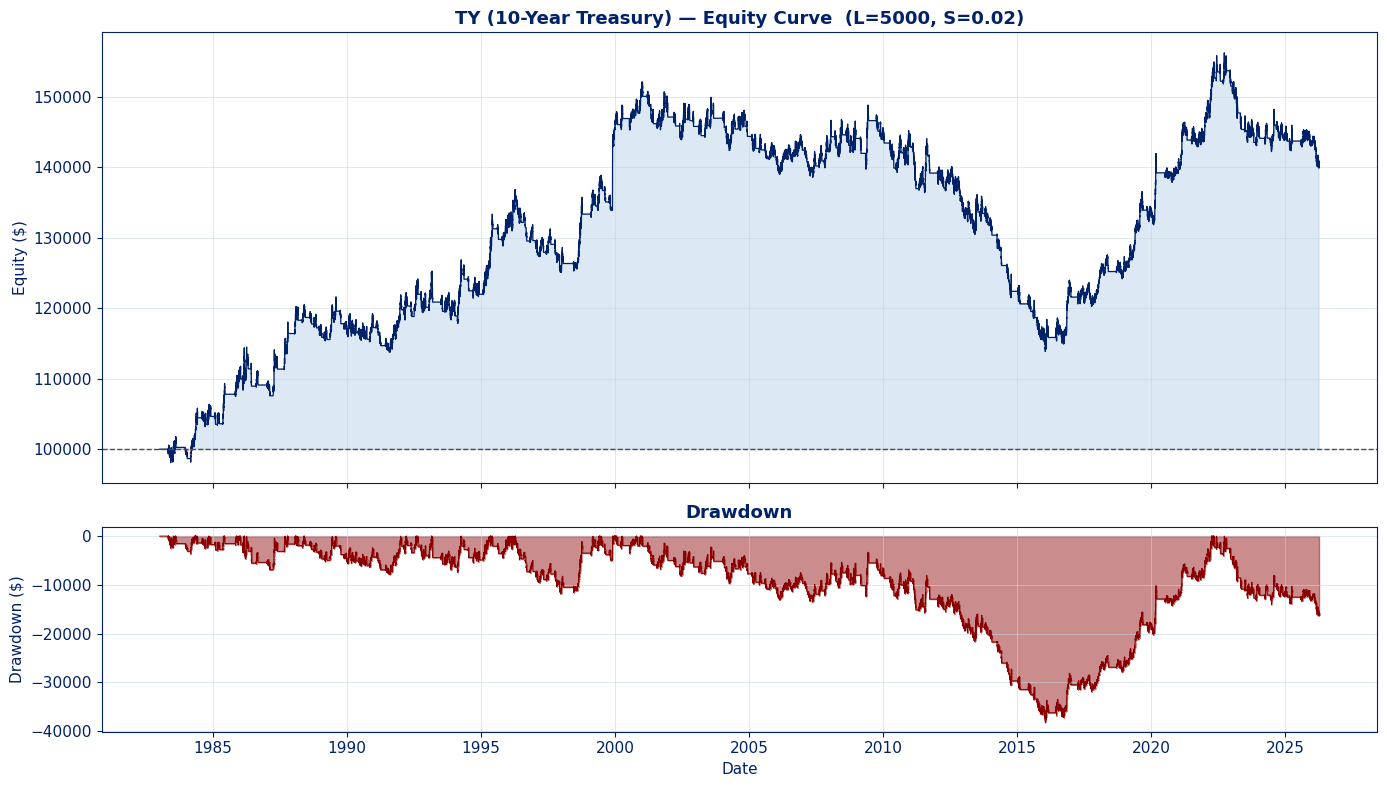

In [8]:
# ============================================================================
# EQUITY CURVE + DRAWDOWN (Columbia theme)
# ============================================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2.2, 1]})

# --- Equity ---------------------------------------------------------------
axes[0].plot(df.index, result['Equity'], color=COLUMBIA_NAVY, linewidth=0.9)
axes[0].fill_between(df.index, result['Equity'], MARKET['E0'],
                     where=result['Equity'] >= MARKET['E0'],
                     color=COLUMBIA_CORE, alpha=0.25,  interpolate=True)
axes[0].fill_between(df.index, result['Equity'], MARKET['E0'],
                     where=result['Equity'] <  MARKET['E0'],
                     color=COLUMBIA_WARM, alpha=0.25,  interpolate=True)
axes[0].axhline(MARKET['E0'], color=COLUMBIA_GREY, linestyle='--', linewidth=1)
axes[0].set_title(f"{TICKER} ({MARKET['name']}) — Equity Curve  "
                  f"(L={test_L}, S={test_S})")
axes[0].set_ylabel('Equity ($)')

# --- Drawdown -------------------------------------------------------------
axes[1].fill_between(df.index, result['Drawdown'], 0,
                     color=COLUMBIA_RED, alpha=0.45)
axes[1].plot(df.index, result['Drawdown'], color=COLUMBIA_RED, linewidth=0.7)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown ($)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

---
## 3. Parameter Grid

In [9]:
# ============================================================================
# PARAMETER GRID  —  coarse (QUICK_TEST=True) or full spec (False)
# ============================================================================
QUICK_TEST = True   # set False for the full 951×96 grid from the assignment

if QUICK_TEST:
    # BTC has fewer bars, so use a shorter channel range
    if TICKER == 'BTC':
        L_values = np.arange(500, 4001, 500)     # 8 values
        S_values = np.arange(0.01, 0.07, 0.01)   # 6 values
    else:
        L_values = np.arange(1000, 10001, 1000)  # 10 values
        S_values = np.arange(0.01, 0.06, 0.01)   # 5 values
else:
    # Full assignment grid: L ∈ {500, 510, ..., 10000}, S ∈ {0.005, 0.006, ..., 0.100}
    L_values = np.arange(500, 10001, 10)
    S_values = np.arange(0.005, 0.101, 0.001)

print(f"Grid for {TICKER}: "
      f"{len(L_values)} × {len(S_values)} = {len(L_values)*len(S_values):,} combinations")
print(f"  L ∈ [{L_values.min()}, {L_values.max()}]")
print(f"  S ∈ [{S_values.min():.3f}, {S_values.max():.3f}]")

Grid for TY: 10 × 5 = 50 combinations
  L ∈ [1000, 10000]
  S ∈ [0.010, 0.050]


---
## 4. Walk-Forward Optimization

In [ ]:
def walk_forward(df, L_values, S_values, T_years=4, tau_quarters=1, slpg=24, PV=1000, E0=100000, verbose=True):
    """
    Walk-Forward Optimization.
    IS = T years, OOS = tau quarters, roll forward by tau.

    Robust to the case where `run_backtest` returns {'error': True}
    (IS or OOS slice too short for the chosen L) — the period is skipped
    cleanly rather than raising KeyError: 'Profit'.
    """
    total_bars = len(df)
    total_days = (df.index.max() - df.index.min()).days
    bars_per_day = total_bars / total_days if total_days > 0 else 78
    bars_per_year = int(bars_per_day * 252)
    bars_per_quarter = int(bars_per_year / 4)

    IS_bars = T_years * bars_per_year
    OOS_bars = tau_quarters * bars_per_quarter

    if verbose:
        print(f"Walk-Forward: IS={T_years}yr ({IS_bars:,} bars), OOS={tau_quarters}Q ({OOS_bars:,} bars)")

    # Cap L so the IS optimizer can never select an L that the OOS slice cannot support.
    # run_backtest requires len(slice) >= max(L+1, 100) + 100, so L <= OOS_bars - 101.
    max_usable_L = OOS_bars - 101
    L_values_capped = np.array([int(L) for L in L_values if int(L) <= max_usable_L], dtype=int)
    if len(L_values_capped) == 0:
        if verbose:
            print(f"  ⚠ All L values exceed OOS capacity ({max_usable_L}). No periods will run.")
        return pd.DataFrame()
    if len(L_values_capped) < len(L_values) and verbose:
        dropped = sorted(set(int(L) for L in L_values) - set(L_values_capped.tolist()))
        print(f"  Note: dropping {len(dropped)} L-values > {max_usable_L} (won't fit in OOS): {dropped}")

    results = []
    current_idx = 0
    period = 1

    while current_idx + IS_bars + OOS_bars <= total_bars:
        is_start = current_idx
        is_end = is_start + IS_bars
        oos_start = is_end
        oos_end = oos_start + OOS_bars

        if verbose:
            print(f"\nPeriod {period}: IS {df.index[is_start].strftime('%Y-%m-%d')} to {df.index[is_end-1].strftime('%Y-%m-%d')}")

        # IS optimization
        best_obj = -np.inf
        best_L, best_S = int(L_values_capped[0]), float(S_values[0])
        best_is = None

        for L in tqdm(L_values_capped, desc=f"Period {period}", leave=False):
            for S in S_values:
                res = run_backtest(df, int(L), float(S), slpg, PV, E0, is_start, is_end)
                if not res.get('error') and res['Objective'] > best_obj:
                    best_obj = res['Objective']
                    best_L, best_S = int(L), float(S)
                    best_is = res

        if best_is is None:
            if verbose:
                print(f"  [IS slice produced no valid parameter set — skipping]")
            current_idx += OOS_bars
            period += 1
            continue

        # OOS evaluation
        oos = run_backtest(df, best_L, best_S, slpg, PV, E0, oos_start, oos_end)

        # Guard: OOS slice can still return {'error': True} in rare edge cases → skip cleanly.
        if oos.get('error'):
            if verbose:
                print(f"  Best: L={best_L}, S={best_S:.3f}")
                print(f"  IS : Profit=${best_is['Profit']:,.0f}, Obj={best_is['Objective']:.3f}")
                print(f"  OOS: [slice too short for L={best_L} — skipping]")
            current_idx += OOS_bars
            period += 1
            continue

        if verbose:
            print(f"  Best: L={best_L}, S={best_S:.3f}")
            print(f"  IS : Profit=${best_is['Profit']:,.0f}, Obj={best_is['Objective']:.3f}")
            print(f"  OOS: Profit=${oos['Profit']:,.0f}, Obj={oos['Objective']:.3f}")

        results.append({
            'Period': period,
            'L': best_L,
            'S': best_S,
            'IS_Profit': best_is['Profit'],
            'IS_Objective': best_is['Objective'],
            'OOS_Profit': oos['Profit'],
            'OOS_Objective': oos['Objective'],
            'OOS_Trades': oos['NumTrades'],
        })

        current_idx += OOS_bars
        period += 1

    return pd.DataFrame(results)

In [11]:
# Run Walk-Forward
print("Starting Walk-Forward Optimization...\n")

wf_results = walk_forward(
    df, L_values, S_values,
    T_years=4, tau_quarters=1,
    slpg=MARKET['slpg'], PV=MARKET['PV'], E0=MARKET['E0'],
    verbose=True
)

Starting Walk-Forward Optimization...

Walk-Forward: IS=4yr (55,100 bars), OOS=1Q (3,443 bars)

Period 1: IS 1983-01-03 to 1986-01-10


Period 1:   0%|          | 0/10 [00:00<?, ?it/s]

  Best: L=2000, S=0.010
  IS: Profit=$11,613, Obj=4.270
  OOS: Profit=$2,334, Obj=1.161

Period 2: IS 1983-03-10 to 1986-03-20


Period 2:   0%|          | 0/10 [00:00<?, ?it/s]

  Best: L=2000, S=0.010
  IS: Profit=$15,193, Obj=5.587
  OOS: Profit=$166, Obj=0.163

Period 3: IS 1983-05-18 to 1986-05-28


Period 3:   0%|          | 0/10 [00:00<?, ?it/s]

  Best: L=2000, S=0.010
  IS: Profit=$16,053, Obj=5.903
  OOS: Profit=$-235, Obj=-0.226

Period 4: IS 1983-07-27 to 1986-08-05


Period 4:   0%|          | 0/10 [00:00<?, ?it/s]

  Best: L=8000, S=0.010
  IS: Profit=$14,185, Obj=5.512


KeyError: 'Profit'

In [ ]:
# Summary
if len(wf_results) > 0:
    print("\n" + "=" * 60)
    print(f"WALK-FORWARD SUMMARY: {TICKER}")
    print("=" * 60)
    print(f"\nPeriods: {len(wf_results)}")
    print(f"Total OOS Profit: ${wf_results['OOS_Profit'].sum():,.2f}")
    print(f"Mean IS Objective: {wf_results['IS_Objective'].mean():.3f}")
    print(f"Mean OOS Objective: {wf_results['OOS_Objective'].mean():.3f}")
    print(f"Decay: {wf_results['OOS_Objective'].mean() / wf_results['IS_Objective'].mean():.1%}")
    print(f"\n{wf_results.to_string(index=False)}")

In [ ]:
# ============================================================================
# WALK-FORWARD VISUALIZATION (Columbia theme)
# ============================================================================
if len(wf_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    x = np.arange(len(wf_results))

    # --- (a) IS vs OOS Profit -------------------------------------------
    axes[0, 0].bar(x - 0.2, wf_results['IS_Profit'] / 1000, 0.4,
                   label='In-Sample',  color=COLUMBIA_CORE,
                   edgecolor=COLUMBIA_NAVY, linewidth=0.6)
    axes[0, 0].bar(x + 0.2, wf_results['OOS_Profit'] / 1000, 0.4,
                   label='Out-of-Sample', color=COLUMBIA_NAVY,
                   edgecolor=COLUMBIA_NAVY, linewidth=0.6)
    axes[0, 0].axhline(0, color=COLUMBIA_GREY, linewidth=1)
    axes[0, 0].set_title('IS vs OOS Profit')
    axes[0, 0].set_ylabel('Profit ($K)')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels([f'P{p}' for p in wf_results['Period']])
    axes[0, 0].legend()

    # --- (b) Objective: IS vs OOS ---------------------------------------
    axes[0, 1].plot(wf_results['Period'], wf_results['IS_Objective'],
                    'o-', color=COLUMBIA_CORE, label='In-Sample', markersize=7)
    axes[0, 1].plot(wf_results['Period'], wf_results['OOS_Objective'],
                    's-', color=COLUMBIA_NAVY, label='Out-of-Sample', markersize=7)
    axes[0, 1].axhline(0, color=COLUMBIA_GREY, linewidth=1)
    axes[0, 1].set_title('Objective (Profit / |MaxDD|)')
    axes[0, 1].set_xlabel('Period')
    axes[0, 1].legend()

    # --- (c) Optimal L & S over time ------------------------------------
    axes[1, 0].plot(wf_results['Period'], wf_results['L'],
                    'o-', color=COLUMBIA_NAVY, label='L (ChnLen)', markersize=7)
    axes[1, 0].set_title('Optimal Parameters by Period')
    axes[1, 0].set_xlabel('Period')
    axes[1, 0].set_ylabel('L', color=COLUMBIA_NAVY)
    axes[1, 0].tick_params(axis='y', labelcolor=COLUMBIA_NAVY)
    ax_s = axes[1, 0].twinx()
    ax_s.plot(wf_results['Period'], wf_results['S'],
              's--', color=COLUMBIA_WARM, label='S (StpPct)', markersize=7)
    ax_s.set_ylabel('S', color=COLUMBIA_WARM)
    ax_s.tick_params(axis='y', labelcolor=COLUMBIA_WARM)
    lines_1, labels_1 = axes[1, 0].get_legend_handles_labels()
    lines_2, labels_2 = ax_s.get_legend_handles_labels()
    axes[1, 0].legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

    # --- (d) Cumulative OOS Equity --------------------------------------
    cum = MARKET['E0'] + wf_results['OOS_Profit'].cumsum()
    axes[1, 1].plot(wf_results['Period'], cum / 1000,
                    '-', color=COLUMBIA_NAVY, linewidth=2)
    axes[1, 1].fill_between(wf_results['Period'], cum / 1000, MARKET['E0'] / 1000,
                            where=cum >= MARKET['E0'], color=COLUMBIA_CORE, alpha=0.3)
    axes[1, 1].fill_between(wf_results['Period'], cum / 1000, MARKET['E0'] / 1000,
                            where=cum <  MARKET['E0'], color=COLUMBIA_WARM, alpha=0.3)
    axes[1, 1].axhline(MARKET['E0'] / 1000, color=COLUMBIA_GREY, linestyle='--')
    axes[1, 1].set_title('Cumulative OOS Equity')
    axes[1, 1].set_xlabel('Period')
    axes[1, 1].set_ylabel('Equity ($K)')

    plt.suptitle(f"{TICKER} ({MARKET['name']}) — Walk-Forward Diagnostics",
                 fontsize=14, color=COLUMBIA_NAVY, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No walk-forward periods produced — check data length vs IS+OOS requirements.")

---
## Next: Notebook 03 - Performance Metrics & Extended Analysis

**End of Notebook 02**